# Step 3：模块三 — 数据血缘全链路追溯

## 痛点故事

**幕一（没有血缘）**：老板问「这张销售订单的煤质数据来自哪批样品？」运维小李翻 SAP 查订单，再翻 LIMS 查样品，又翻 PI 查矿井读数——三个系统问三个人，半天还串不起来，最后靠一张手填的 Excel 对上了。

**幕二（有血缘）**：在 DataHub 里点开这张订单，血缘图自动画出 `vbak → lims.samples → pi_system.tags` 的来源链路，5 分钟看到每批煤的化验来源与矿井读数，不用再翻三个系统。

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────
# 把 src/ 加入 Python 路径
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

import json
import subprocess
import pandas as pd
from dg_education import (
    load_lineage_graph,
    upstream, downstream, blast_radius, ancestors, render_ascii, edge_list,
    plot_lineage_graph, plot_blast_radius,
)

# recipe 路径（项目根目录）
REPO_ROOT = os.path.dirname(os.getcwd())
RECIPE_PATH = os.path.join(REPO_ROOT, 'lineage_recipe.yaml')
DATA_ROOT = os.path.join(REPO_ROOT, 'data', 'historical')
QUERY_SCRIPT = os.path.join(REPO_ROOT, 'scripts', 'query_lineage.py')

print(f'RECIPE_PATH = {RECIPE_PATH}')
print(f'已加载模块三血缘 API（load_lineage_graph / upstream / downstream / blast_radius / render_ascii）')

RECIPE_PATH = /home/szs/Playground/dg-demo/lineage_recipe.yaml
已加载模块三血缘 API（load_lineage_graph / upstream / downstream / blast_radius / render_ascii）


## 3 步学习节奏

| 步骤 | 主题 | 你能学会什么 |
|------|------|-------------|
| 步骤 1 | 血缘是什么 | 两类血缘（业务/加工）+ 当前 8 条边的全局图 |
| 步骤 2 | 上下游追溯 | 从任一节点追根溯源 + 评估影响面，并对比 DataHub 真图 |
| 步骤 3 | 影响面实战 | 煤质异常会波及哪些下游，以及诚实面对「数据孤岛」 |

> **本 notebook 与 DataHub UI 的边界**：本 notebook 离线分析血缘图（从 `lineage_recipe.yaml` 读取），DataHub UI 是线上协作平台展示同一张图。需要看 DataHub 里真实写入的血缘时，本 notebook 通过 `subprocess` 调用只读脚本 `scripts/query_lineage.py`（notebook 不直连 GMS/OpenSearch）。

## 步骤 1：血缘是什么 —— 8 条边的全局图

**血缘（Lineage）** 记录数据从源到目标的流转路径，回答两个问题：
- **追根溯源**：这份数据从哪来？（上游）
- **影响评估**：这份数据出问题会影响谁？（下游）

本项目有两类血缘：
| 类型 | 含义 | 示例 |
|------|------|------|
| 业务血缘 | 跨系统按业务语义关联（非字面 JOIN） | `sap_erp.vbak → lims.samples`（订单的煤在 LIMS 化验） |
| 加工血缘 | ODS→DWD / DWD→DWA 的 ETL 派生 | `sap_erp.vbak → dwd.vbak → dwa_sales_daily` |

下面是从 `lineage_recipe.yaml` 读取的 8 条边全局图：

In [2]:
g = load_lineage_graph(RECIPE_PATH)
print(render_ascii(g))

血缘图（上游 → 下游，数据流向自上而下）

【sap_erp 层】
  sap_erp.vbak (源头)
      ↓ dwd.vbak
      ↓ lims.samples
  sap_erp.vbap (源头)
      ↓ lims.samples

【pi_system 层】
  pi_system.tags (源头)
      ↓ dwa.dwa_tag_alarm
      ↓ dwd.tags

【lims 层】
  lims.samples
      ↑ sap_erp.vbak
      ↑ sap_erp.vbap
      ↓ dwa.dwa_coal_quality
      ↓ dwd.samples

【dwd 层】
  dwd.samples
      ↑ lims.samples
  dwd.tags
      ↑ pi_system.tags
  dwd.vbak
      ↑ sap_erp.vbak
      ↓ dwa.dwa_sales_daily

【dwa 层】
  dwa.dwa_coal_quality
      ↑ lims.samples
  dwa.dwa_sales_daily
      ↑ dwd.vbak
  dwa.dwa_tag_alarm
      ↑ pi_system.tags
节点 10 / 边 8


### 可视化：分层血缘图

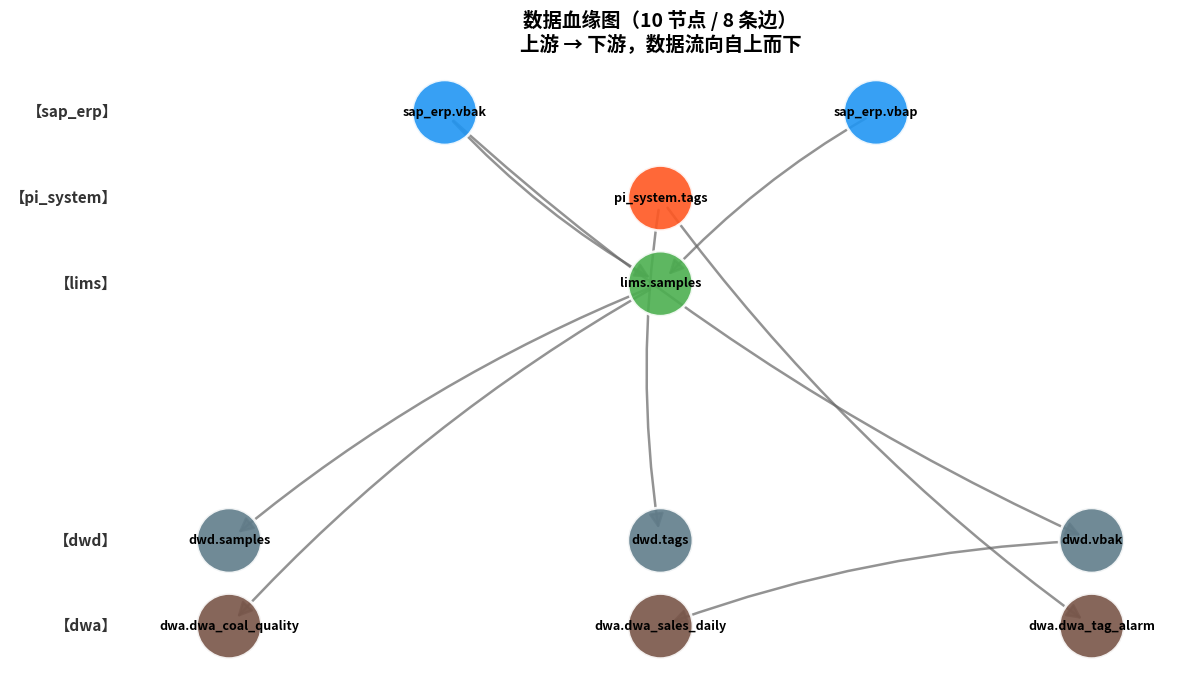

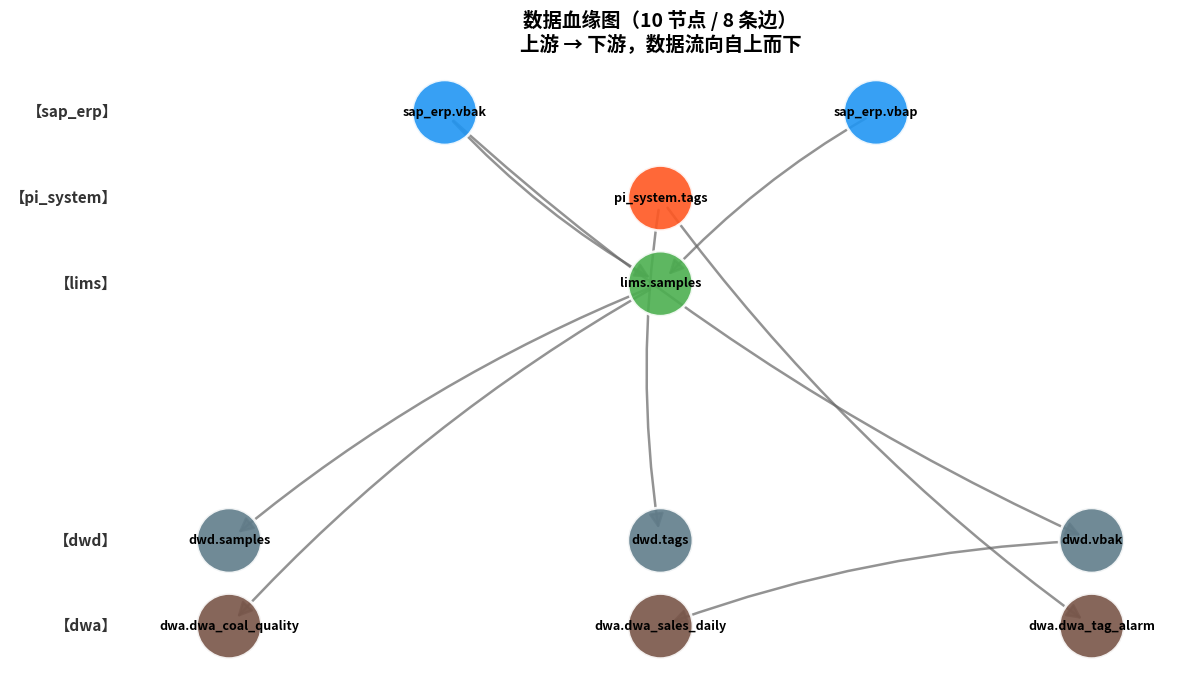

In [4]:
plot_lineage_graph(g)

## 步骤 2：上下游双向追溯

### 2.1 上游追溯（追根溯源）

**业务问题**：「`lims.samples` 这批煤质数据，其业务来源是哪些 SAP 订单？」

从 `lims.samples` 向上找上游，得到 `sap_erp.vbak` 和 `sap_erp.vbap`——这正是模块三「跨系统血缘」的核心卖点。

> ⚠️ **诚实说明**：这两条是**业务血缘**——`lims.samples` 没有 KUNNR 列、`vbak` 没有 MINE_CODE 列，两表无字面共享列，无法直接 JOIN。此边表达「客户订购的煤曾在某矿井化验」的业务语义，真实跨系统关联键的统一属 Phase 2 / 模块七主数据标准化范围。

In [5]:
target = 'lims.samples'
print(f'【上游追溯】{target} 的直接上游：')
for u in upstream(g, target):
    print(f'  ← {u}')
print(f'\n【全链溯源】{target} 的所有上游（拓扑序）：')
for a in ancestors(g, target):
    print(f'  ← {a}')

【上游追溯】lims.samples 的直接上游：
  ← sap_erp.vbak
  ← sap_erp.vbap

【全链溯源】lims.samples 的所有上游（拓扑序）：
  ← sap_erp.vbak
  ← sap_erp.vbap


### 2.2 下游追溯（影响评估）

**业务问题**：「`lims.samples` 的数据会被哪些下游表用到？」

从 `lims.samples` 向下找下游，得到 DWD 清洗表和 DWA 月度煤质宽表——这批样品一旦出错，这两个下游都受影响。

In [6]:
print(f'【下游追溯】{target} 的直接下游：')
for d in downstream(g, target):
    print(f'  → {d}')
print(f'\n【影响面 blast-radius】{target} 数据异常波及的全部下游：')
for b in blast_radius(g, target):
    print(f'  → {b}')

【下游追溯】lims.samples 的直接下游：
  → dwa.dwa_coal_quality
  → dwd.samples

【影响面 blast-radius】lims.samples 数据异常波及的全部下游：
  → dwd.samples
  → dwa.dwa_coal_quality


### 2.3 对比 DataHub 真图（经只读脚本查询）

上面是从 recipe 自建的血缘图。DataHub 里真正写入的血缘是否一致？

本 notebook **不直连 GMS**，而是通过 `subprocess` 调用只读脚本 `scripts/query_lineage.py`，让它去查 DataHub 已写入的 `upstreamLineage` aspect，返回 JSON。我们再离线对比二者边是否一致。

> 需要 DataHub 服务已启动并已跑过 `emit_lineage.py`。若服务未启动，脚本会返回空上游（本 notebook 仍可离线演示 recipe 图）。

In [7]:
# 经 subprocess 调用只读脚本，拿 DataHub 真图（notebook 不直连服务）
result = subprocess.run(
    ['python', QUERY_SCRIPT, '--recipe', RECIPE_PATH],
    capture_output=True, text=True, cwd=REPO_ROOT,
)
if result.returncode == 0 and result.stdout.strip():
    real = json.loads(result.stdout)
    real_edges = set()
    for rec in real:
        ds = rec['dataset']
        for up_short in rec.get('upstreams_short', []):
            real_edges.add((up_short, ds))
    recipe_edges = {(e['upstream'], e['downstream']) for e in edge_list(g)}
    print(f'DataHub 真图边数: {len(real_edges)}')
    print(f'recipe 自建图边数: {len(recipe_edges)}')
    print(f'\n二者一致的边: {len(real_edges & recipe_edges)}')
    only_recipe = recipe_edges - real_edges
    only_real = real_edges - recipe_edges
    if only_recipe: print(f'仅 recipe 有: {only_recipe}')
    if only_real: print(f'仅 DataHub 有: {only_real}')
    if not only_recipe and not only_real and real_edges:
        print('\n✅ recipe 自建图与 DataHub 真图完全一致')
else:
    print('⚠️ DataHub 服务未启动或未写入血缘（stderr 见下），本 notebook 继续离线演示 recipe 图')
    print(result.stderr[:300] if result.stderr else '(无 stderr)')

DataHub 真图边数: 0
recipe 自建图边数: 8

二者一致的边: 0
仅 recipe 有: {('sap_erp.vbak', 'lims.samples'), ('sap_erp.vbap', 'lims.samples'), ('sap_erp.vbak', 'dwd.vbak'), ('lims.samples', 'dwd.samples'), ('dwd.vbak', 'dwa.dwa_sales_daily'), ('lims.samples', 'dwa.dwa_coal_quality'), ('pi_system.tags', 'dwa.dwa_tag_alarm'), ('pi_system.tags', 'dwd.tags')}


## 步骤 3：影响面实战 —— 煤质异常波及谁

**业务剧本**：煤质中心发现 `lims.samples` 里某矿井灰分异常超标，要评估影响面。

沿血缘图从 `lims.samples` 向下追溯，得到受影响的下游：DWD 清洗表 + DWA 月度煤质宽表。其中 `dwa_coal_quality` 直接依赖这批样品——煤质异常会直接污染月度煤质报表。

【业务影响】lims.samples 煤质异常将波及 2 个下游：
  → dwd.samples：DWD 清洗表（下游报表基础）
  → dwa.dwa_coal_quality：DWA 月度煤质报表（直接污染）

责任部门：煤质中心（源头数据质量）+ 销售部（受影响的定价报表）


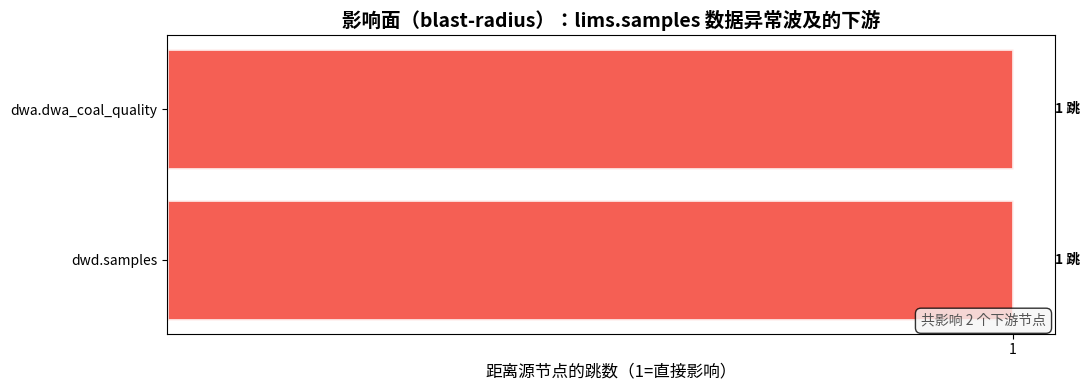

In [8]:
source = 'lims.samples'
fig = plot_blast_radius(g, source)

# 业务影响白话翻译
impacted = blast_radius(g, source)
print(f'【业务影响】{source} 煤质异常将波及 {len(impacted)} 个下游：')
for n in impacted:
    hops = len(impacted)  # 简化：列出即可
    role = 'DWA 月度煤质报表（直接污染）' if 'coal_quality' in n else 'DWD 清洗表（下游报表基础）'
    print(f'  → {n}：{role}')
print('\n责任部门：煤质中心（源头数据质量）+ 销售部（受影响的定价报表）')

### 诚实面对：跨系统全链尚未打通（数据孤岛）

当前血缘图只覆盖 **8 条边**。Background.md §6.3 承诺的「产销全链」——`pi_system.tags → lims.samples（CHARG）→ sap_erp.vbap → vbak → kna1 → oa.contract`——**尚未建立**。

**原因（诚实）**：源系统间无字面共享关联键。LIMS 用 CHARG 批次号、SAP 用 VBELN/KUNNR、PI 用 MINE_CODE 编码标签，三套编码体系不统一——这正是本项目要治理的「数据孤岛」本身。打通全链需要先做主数据编码标准化（模块七），属 Phase 2 范围。

**所以模块三演示的「全链路追溯」目前能做到**：单系统内 ODS→DWD→DWA 全链 + 跨系统业务语义关联（声明式）。**暂时做不到**：PI↔LIMS↔SAP 的字面可执行 JOIN 全链。

> 这不是「做不出来」，而是「数据治理的真实进度」——血缘图的缺口本身就是治理待办的可视化。

## 附加：DataHub UI Lineage 标签页

教学 notebook 是离线分析，DataHub UI 是线上协作平台展示同一张血缘图。在浏览器打开 `http://localhost:29002`，搜索 `lims` 进入 `lims.samples` dataset，切到 **Lineage** 标签页，即可看到与上图一致的上下游。

**延迟说明**：写入血缘后 UI 约 5-30 秒出现。链路为 GMS 写入 → Kafka MAE 事件 → datahub-actions 消费 → OpenSearch 索引刷新（OS 默认 refresh 1s，瓶颈在 actions 消费）。演示前请先跑：

```bash
# 1. 注册 DWA 表为 dataset（含血缘下游节点）
uv run python scripts/emit_via_rest_emitter.py
# 2. 写入 8 条血缘边
uv run python scripts/emit_lineage.py
# 3. 真验证（断言 aspect 非空 + 索引同步）
uv run python scripts/verify_lineage.py
```

## 模块三总结

| 学到了什么 | 关键点 |
|-----------|--------|
| 血缘两类 | 业务血缘（跨系统语义）+ 加工血缘（ETL 派生） |
| 双向追溯 | upstream 追根溯源 / downstream 评估影响 |
| 影响面 | blast-radius 传递闭包，定位污染范围 |
| 分层纪律 | notebook 离线 + 只读脚本联网，不直连服务 |
| 诚实治理 | 全链缺口 = 数据孤岛 = 治理待办，不粉饰 |

**前置模块**：
- `notebook/module1.ipynb` —— 模块一：数据资产可视化（看资产）
- `notebook/module2.ipynb` —— 模块二：数据质量检测与根因定位（找问题）
- 本模块三：数据血缘全链路追溯（追血缘）

**后续**：模块四（清洗）/模块五（ELT+DWA），以及 Phase 2 的自动血缘采集（模块九）与主数据标准化（模块七，打通跨系统全链的钥匙）。